/home/anwaldt/DEVELOP/dsp_venv/lib/python3.12/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


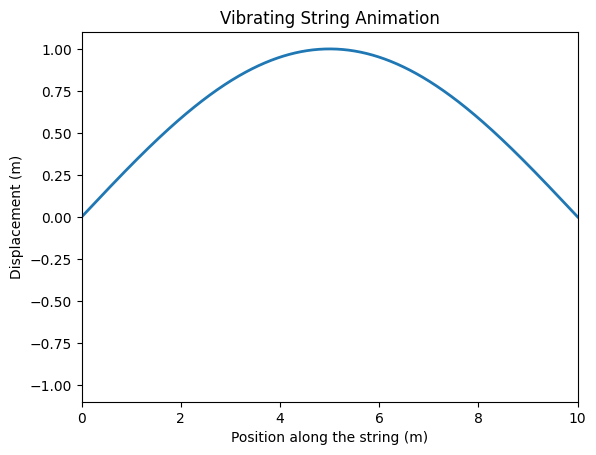

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Parameters
L = 10.0  # Length of the string (in meters)
T = 1.0  # Tension (not used explicitly here but typically involved in wave velocity)
rho = 0.01  # Mass per unit length
c = np.sqrt(T / rho)  # Wave speed
f0 = 1.0  # Fundamental frequency (in Hz)
omega = 2 * np.pi * f0  # Angular frequency (in rad/s)
k = np.pi / L  # Wave number for the fundamental mode

# Discretization of space
x = np.linspace(0, L, 1000)

# Traveling wave with reflection at both ends
def string_position(x, t):
    # Traveling wave reflected at both ends
    return np.sin(k * x - omega * t) - np.sin(k * x + omega * t)

# Set up the plot
fig, ax = plt.subplots()
line, = ax.plot(x, string_position(x, 0), lw=2)
ax.set_xlim(0, L)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel('Position along the string (m)')
ax.set_ylabel('Displacement (m)')
ax.set_title('Traveling and Reflected Wave on the String')

# Update function for the animation
def update(t):
    y = string_position(x, t)
    line.set_ydata(y)
    return line,

# Create the animation
ani = FuncAnimation(fig, update, frames=np.linspace(0, 2 * np.pi / omega, 100), interval=50)

# Display animation in the notebook
HTML(ani.to_jshtml())
